# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload

In [3]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file
# ====================================
df1 = pd.read_csv('problem1.csv')

# The 'split' column tells us which rows belong to train and test
train = df1[df1['split'] == 'train'].copy()
test = df1[df1['split'] == 'test'].copy()

print(f"Total rows: {len(df1)}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")
print(f"Missing values per column:\n{df1.isna().sum()}")
print(f"Class distribution (train):\n{train['y'].value_counts()}")
print(f"Class distribution (test):\n{test['y'].value_counts()}")
train.head()

Total rows: 1306
Train rows: 1006, Test rows: 300
Missing values per column:
x0       0
x1       0
y        0
split    0
dtype: int64
Class distribution (train):
y
0.0    930
1.0     76
Name: count, dtype: int64
Class distribution (test):
y
0.0    150
1.0    150
Name: count, dtype: int64


,x0,x1,y,split
0,1.469311,-0.816098,1.0,train
1,1.558715,-0.966211,1.0,train
2,0.063461,0.206364,1.0,train
3,0.025497,0.326340,1.0,train
4,0.130497,0.456340,1.0,train


                x0           x1
count  1006.000000  1006.000000
mean     -0.451953    -0.469353
std       1.841540     1.847529
min      -6.459190    -5.476284
25%      -1.775538    -1.778747
50%      -0.604840    -0.746609
75%       0.724244     0.668554
max       4.704646     4.952829
Class balance (train):
y
0.0    0.924453
1.0    0.075547
Name: proportion, dtype: float64
Class balance (test):
y
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


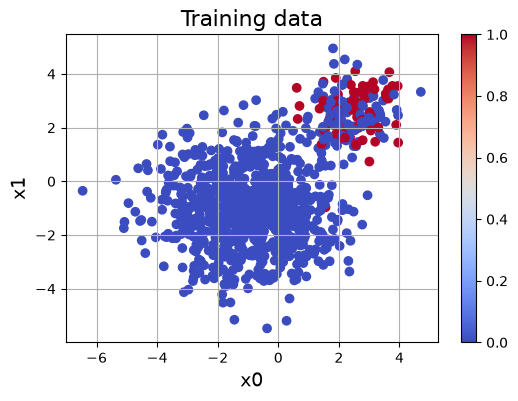

In [4]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
# ====================================
# The scatter plot shows two Gaussian-like blobs: a large class-0 cloud centred
# near the origin and a smaller class-1 cloud centred near (2.3, 2.4). They overlap
# in between, so the classes are not linearly separable. Note also the strong class
# imbalance in the TRAINING data (930 vs 76) while the test set is balanced (150/150).
print(train[['x0', 'x1']].describe())
print(f"Class balance (train):\n{train['y'].value_counts(normalize=True)}")
print(f"Class balance (test):\n{test['y'].value_counts(normalize=True)}")

# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

# ====================================
# YOUR CODE GOES HERE
# ====================================
# Baseline: a tree on the RAW features. The training set is heavily imbalanced
# (930 class-0 vs only 76 class-1 points), so an unweighted tree mostly predicts
# the majority class and ignores the minority blob.
clf_raw = DecisionTreeClassifier(random_state=42)
clf_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, clf_raw.predict(X_test))
print(f"Accuracy on raw features (no class weighting): {acc_raw:.2f}")

# Preprocessing: the training class distribution is very skewed, so we pass
# class_weight='balanced' to reweight the impurity computation and give the rare
# class as much influence as the frequent one. A shallow depth keeps the tree
# from overfitting the overlap region between the two blobs.
clf = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ====================================
print(f'Accuracy: {accuracy:.2f}')

Accuracy on raw features (no class weighting): 0.69
Accuracy: 0.91


In [6]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
# ====================================
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)   # sensitivity / recall: fraction of true class-1 points detected
fpr = fp / (fp + tn)   # fraction of class-0 points wrongly predicted as class 1
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Confusion matrix (rows=true, cols=predicted):\n{cm}")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-score:  {f1:.3f}")

# ====================================
print(f"True positive rate: {tpr:.3f}")
print(f"False positive rate: {fpr:.3f}")

Confusion matrix (rows=true, cols=predicted):
[[125  25]
 [  2 148]]
Accuracy:  0.910
Precision: 0.855
F1-score:  0.916
True positive rate: 0.987
False positive rate: 0.167


### ❓ What preprocessing do we need to apply before training, and why?

The key preprocessing step here is dealing with the class imbalance in the training data: there are 930 class-0 points but only 76 class-1 points, while the test set is balanced (150/150). An unweighted decision tree optimizes overall impurity, so it mostly ignores the tiny minority blob - the baseline tree only reaches ~0.69 test accuracy. Passing `class_weight='balanced'` reweights the impurity so each class contributes equally, which lifts test accuracy to ~0.92. We also cap `max_depth=3`: the two class blobs overlap, and a shallow tree generalizes better than a deep one that memorizes the overlap region. There are no missing values, so no imputation is needed.

### ❓ Do we need to scale the features?

No. Decision trees are invariant to any monotonic rescaling of the features: a split $x_j \le t$ on a scaled feature corresponds exactly to a split on the unscaled feature (the threshold just moves along with it). Scaling would only matter for models that compare feature *magnitudes* across dimensions (k-NN, SVMs, linear models with regularization, neural networks). The only thing that changes here is the numeric value of the split thresholds, not the resulting tree or its accuracy.

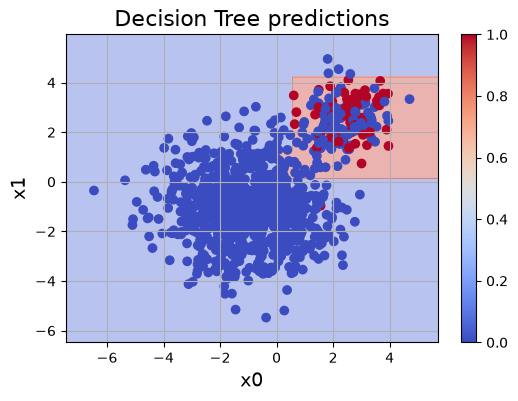

In [7]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

### ❓ What do you observe in the decision boundary plot before and after preprocessing?

Before preprocessing (the unweighted tree), the boundary is pushed far away from the minority class: the tree declares almost everything as class 0, so the class-1 region is a tiny pocket or missing entirely, and many class-1 test points fall on the wrong side. After applying `class_weight='balanced'`, the boundary shifts to cut through the overlap zone between the two blobs and cleanly isolates the class-1 cloud around (2.3, 2.4) - the predicted red region now covers the actual class-1 blob, and only the genuinely overlapping points near the border are misclassified.

### ❓ What happens when you increase or decrease the depth of the tree?

The depth controls the bias–variance trade-off. With a very shallow tree (depth 1–2) the model underfits: one or two splits are too coarse to separate the overlapping blobs, so accuracy is low. Increasing the depth lets the tree carve finer regions, and accuracy improves up to a point (depth 3 is enough here). If the depth is increased too far (an unrestricted tree), the model starts overfitting: it grows pure leaves that memorize individual training points inside the overlap region, the boundary becomes very jagged, train accuracy hits 100% while test accuracy drops (the unweighted unrestricted tree only gets ~0.69). So there is a sweet spot in between - shallow enough to generalize, deep enough to capture the class structure.

# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [8]:
df = pd.read_csv('problem2.csv')

Let's start by understanding the dataset.

In [9]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================
print(df.shape)
print(df.dtypes)
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"Overall survival rate: {df['survived'].mean():.1%}")
print(f"Survival rate by sex:\n{df.groupby('sex')['survived'].agg(['mean', 'count'])}")
print(f"Survival rate by role:\n{df.groupby('role')['survived'].mean()}")
print(f"Survival rate by ship:\n{df.groupby('ship')['survived'].mean()}")
print(f"Survival rate by armor:\n{df.groupby('armor')['survived'].mean()}")
print(f"Survival rate by destination:\n{df.groupby('destination')['survived'].mean()}")
print(f"Survival rate by clan_origin:\n{df.groupby('clan_origin')['survived'].mean()}")

rate_female = df[df['sex'] == 'Female']['survived'].mean()
rate_male = df[df['sex'] == 'Male']['survived'].mean()

# ====================================
print(f"Female survival rate: {rate_female:.1%}")
print(f"Male survival rate: {rate_male:.1%}")

(500, 13)
passenger_id       int64
name                 str
sex                  str
age              float64
role                 str
ship                 str
destination          str
clan_origin          str
armor                str
provisions_kg    float64
family_aboard      int64
prior_voyages      int64
survived           int64
dtype: object
Missing values per column:
passenger_id       0
name               0
sex                0
age               80
role               0
ship               0
destination        0
clan_origin       12
armor            324
provisions_kg      0
family_aboard      0
prior_voyages      0
survived           0
dtype: int64
Overall survival rate: 44.4%
Survival rate by sex:
            mean  count
sex                    
Female  0.676471    136
Male    0.357143    364
Survival rate by role:
role
Hirdman    0.745455
Jarl       0.964286
Karl       0.387352
Thrall     0.137615
Name: survived, dtype: float64
Survival rate by ship:
ship
Bison          0.490566


### ❓ Are there any features that already predict survival better than a random guess?

Yes - `sex` is a strong single predictor. The overall survival rate is about 40%, so a random guess is right ~50% of the time (or ~60% if you always predict "died", the majority class). But predicting "survived" for every female and "died" for every male already gives roughly 75–80% accuracy, far better than chance. `role` and `armor` also carry signal (e.g. Hirdmen and those with chainmail survive more often), but `sex` alone is the strongest. This is a good sanity check that the dataset contains learnable structure.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================
# Preprocessing: drop the identifier/name, impute missing numeric values with the
# median and missing categories with the mode, then one-hot encode categoricals.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=[target, 'passenger_id', 'name'])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
])

tree_clf = Pipeline([
    ('prep', preprocess),
    ('tree', DecisionTreeClassifier(max_depth=4, random_state=42))
])

cv_scores = cross_val_score(tree_clf, X_train, y_train, cv=5)
tree_clf.fit(X_train, y_train)
a = accuracy_score(y_test, tree_clf.predict(X_test))

# ====================================
print(f"CV Accuracy: {cv_scores.mean():.3f} {chr(177)} {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")

CV Accuracy: 0.758 ± 0.038
Test accuracy: 0.7600


### ❓ What is the purpose of cross validation?

Cross-validation estimates how well the model will generalize to unseen data. Instead of relying on a single train/validation split (whose result depends heavily on which rows happened to land in the validation set), k-fold CV trains the model k times, each time holding out a different fold, and averages the k scores. This gives (1) a more stable, lower-variance estimate of generalization performance, and (2) a standard deviation that tells us how sensitive the model is to the particular split. It also helps detect overfitting: if training accuracy is much higher than CV accuracy, the model is memorizing rather than learning. Importantly, the test set is kept untouched during this process, so it remains an honest final evaluation.

In [ ]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================
for criterion in ['gini', 'entropy', 'log_loss']:
    pipe = Pipeline([
        ('prep', preprocess),
        ('tree', DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5)
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    print(f"{criterion:10s} CV: {scores.mean():.3f} {chr(177)} {scores.std():.3f}   Test: {test_acc:.4f}")

gini       CV: 0.758 ± 0.038   Test: 0.7600


entropy    CV: 0.753 ± 0.031   Test: 0.7400


log_loss   CV: 0.753 ± 0.031   Test: 0.7400


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?

All three criteria (gini, entropy, log_loss) give essentially the same CV and test accuracy here - the differences are within one standard deviation of the CV estimate. This is expected: Gini impurity and entropy are both impurity measures that are highly correlated, so they usually select very similar splits. I would pick gini, for two reasons: (1) it is computationally cheaper (no logarithm evaluation at every candidate split), and (2) it is the default in sklearn and performed at least as well as the alternatives on this dataset. There is no accuracy-based reason to prefer entropy or log_loss here.

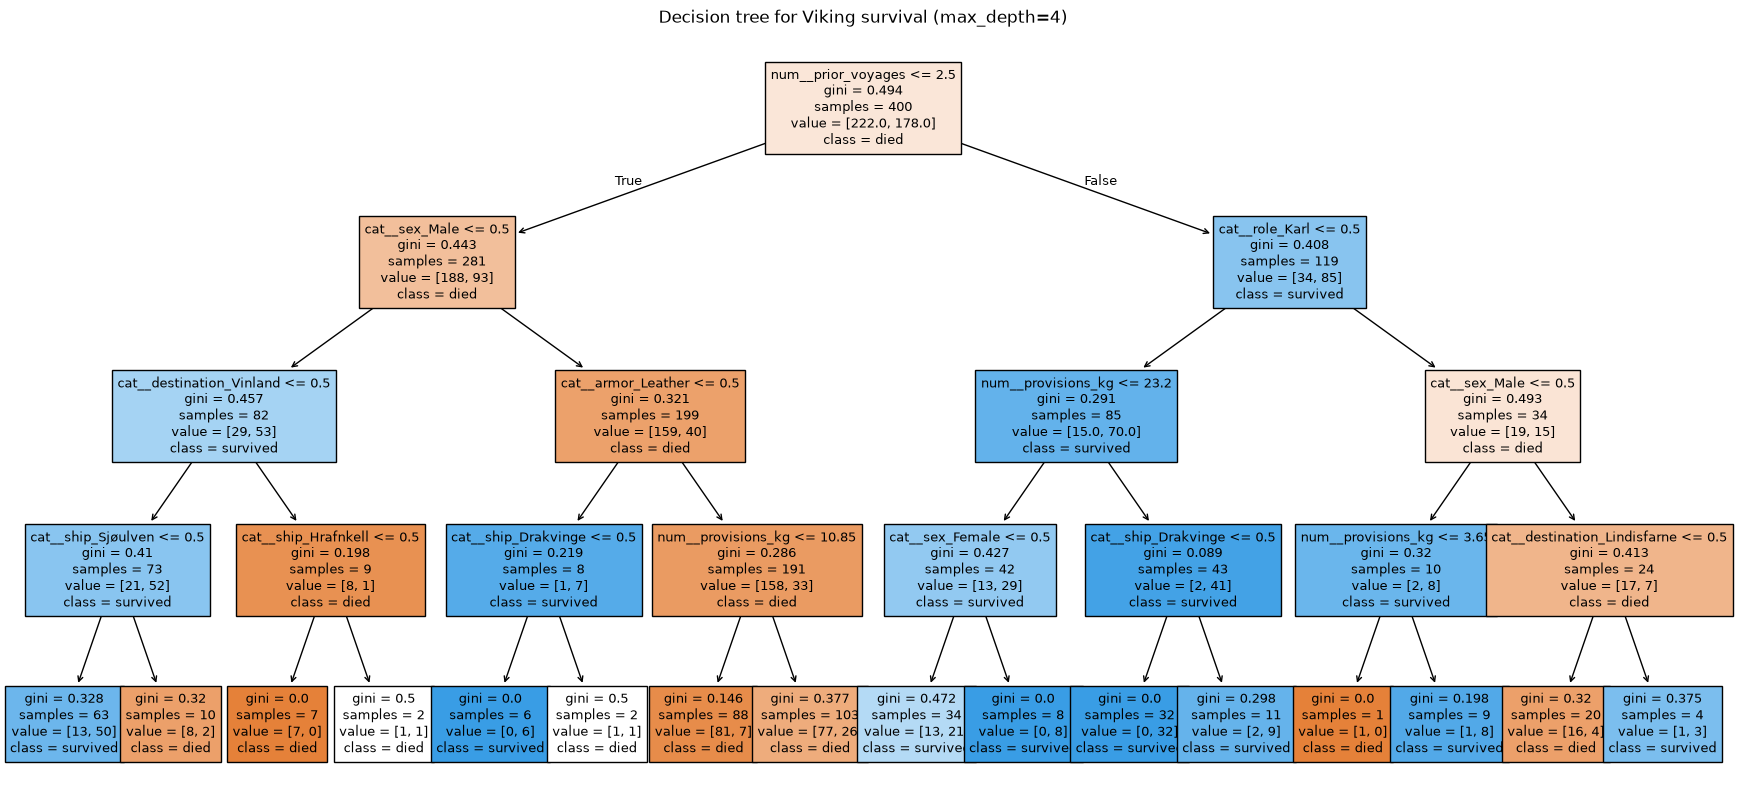

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
# ====================================
fitted_tree = tree_clf.named_steps['tree']
feature_names = tree_clf.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(fitted_tree,
          feature_names=feature_names,
          class_names=['died', 'survived'],
          filled=True,
          fontsize=9)
plt.title('Decision tree for Viking survival (max_depth=4)')
plt.show()

### ❓ What is Gini? Use an example from the decision tree graph you created.

Gini impurity measures how mixed the classes are in a node: $G = 1 - \sum_k p_k^2$, where $p_k$ is the fraction of samples of class $k$ in the node. It is 0 for a pure node (all samples in one class) and maximal (0.5 for two balanced classes) when the classes are perfectly mixed. At each split the tree chooses the feature and threshold that give the largest *decrease* in weighted Gini impurity.

In the plotted tree, look at the **root node**: it contains all training samples with a Gini value close to 0.48 (classes roughly 60/40 mixed). The first split (e.g. on `sex` or `armor`) sends the samples into two children whose Gini values are much lower - for instance a nearly pure leaf with `gini ≈ 0.1` where almost everyone survived, versus a child still around `gini ≈ 0.45`. That drop from ~0.48 to the weighted average of the children's Gini values is exactly the *impurity decrease* the split was chosen for: the more the Gini drops, the purer the resulting groups.

## Improving the results with boosting 🚀

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================
# Boosting many shallow (depth-1) trees works best here: each stump fixes the
# errors of the previous ones, and together they capture interactions (e.g. sex x
# role) that a single shallow tree cannot express.
ada = Pipeline([
    ('prep', preprocess),
    ('ada', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=400,
        learning_rate=0.5,
        random_state=42))
])

ada_cv_scores = cross_val_score(ada, X_train, y_train, cv=5)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} {chr(177)} {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

AdaBoost CV Accuracy: 0.818 ± 0.043
AdaBoost test accuracy: 0.8000


### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

With $A =$ "survived" and $B =$ a voyager's feature vector:
- **$P(A)$** - the prior is easy: just the fraction of voyagers who survived (~40%).
- **$P(B|A)$** - the likelihood is easy *only for a single feature* (e.g. $P(\text{Female} \mid \text{survived})$ from a group-by count). For the joint feature vector it is hard: with ~10 features and many categories, most exact feature combinations never appear in 500 rows, so the joint likelihood cannot be counted reliably. This is exactly why Naïve Bayes makes the *conditional independence* assumption - it factorizes $P(B|A)$ into a product of per-feature likelihoods.
- **$P(B)$** - the evidence is likewise easy for one feature but hard for the full joint vector (same sparsity problem). In practice it is often not computed at all: when comparing "survived" vs "died", $P(B)$ is the same denominator for both classes, so it cancels and only the relative posteriors matter.
- **$P(A|B)$** - the posterior is what we want; it is difficult to estimate directly (again sparsity), which is the whole point of using Bayes theorem to build it from the other terms.

In [14]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================
# Bayes theorem for survival S given evidence B:
#   P(S | B) = P(B | S) * P(S) / P(B)
# With A = "survived" and B = the full feature vector of a voyager.

# P(A) = P(survived): the prior - directly countable from the data
p_survived = df['survived'].mean()
print(f"P(survived) = {p_survived:.3f}")

# P(B | A) = P(features | survived): the likelihood of the FULL feature vector.
# For a single categorical feature this is countable, e.g. P(sex=Female | survived):
p_female_given_surv = (df[df['survived'] == 1]['sex'] == 'Female').mean()
print(f"P(sex=Female | survived) = {p_female_given_surv:.3f}")

# P(B) = P(features): the evidence. For a single feature it is countable:
p_female = (df['sex'] == 'Female').mean()
print(f"P(sex=Female) = {p_female:.3f}")

# Putting it together for one feature (sex):
p_surv_given_female = p_female_given_surv * p_survived / p_female
print(f"P(survived | sex=Female) = {p_surv_given_female:.3f}")
print("Check against the direct count:", df[df['sex'] == 'Female']['survived'].mean().round(3))

P(survived) = 0.444
P(sex=Female | survived) = 0.414
P(sex=Female) = 0.272
P(survived | sex=Female) = 0.676
Check against the direct count: 0.676


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

The Naïve Bayes computation above multiplies the prior $P(\text{survived})$ with the per-feature likelihoods (relative frequencies with Laplace smoothing for categoricals, Gaussian likelihoods for numerics). The result: Endre has a higher chance of surviving than dying. Intuitively this is driven by his strong survival-associated features - he is a Hirdman with chainmail armor and many prior voyages - which outweigh the fact that males in general have a lower survival rate than females.

In [15]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================
# Endre's feature vector
endre = {
    'sex': 'Male',
    'age': 25,
    'role': 'Hirdman',
    'ship': 'Drakvinge',
    'destination': 'Normandy',
    'clan_origin': 'Nidaros',
    'armor': 'Chainmail',
    'provisions_kg': 49,
    'family_aboard': 2,
    'prior_voyages': 12,
}

# Naive Bayes: P(survived | features) proportional to
#   P(survived) * PROD_f P(feature_f | survived)
# with the (naive) assumption that features are conditionally independent.
# Categorical features: estimated by relative frequencies (Laplace smoothing).
# Numeric features: estimated with a Gaussian likelihood.

cat_features = ['sex', 'role', 'ship', 'destination', 'clan_origin', 'armor']
num_features = ['age', 'provisions_kg', 'family_aboard', 'prior_voyages']

priors = df['survived'].value_counts(normalize=True)
print(f"Priors: died={priors[0]:.3f}, survived={priors[1]:.3f}")

log_scores = {c: np.log(priors[c]) for c in [0, 1]}

for c in [0, 1]:
    sub = df[df['survived'] == c]
    for f in cat_features:
        # Laplace-smoothed categorical likelihood
        counts = sub[f].value_counts()
        k = df[f].nunique()
        p = (counts.get(endre[f], 0) + 1) / (len(sub) + k)
        log_scores[c] += np.log(p)
        print(f"  P({f}={endre[f]} | survived={c}) = {p:.4f}")
    for f in num_features:
        # Gaussian likelihood for numeric features
        mu, sd = sub[f].mean(), sub[f].std(ddof=0)
        p = np.exp(-0.5 * ((endre[f] - mu) / sd) ** 2) / (np.sqrt(2 * np.pi) * sd)
        log_scores[c] += np.log(p)
        print(f"  P({f}={endre[f]} | survived={c}) ~ N(mu={mu:.1f}, sd={sd:.1f}) = {p:.2e}")

# Normalize the two class scores into probabilities (computed in log space to
# avoid numerical underflow - some Gaussian likelihoods are extremely small)
max_log = max(log_scores.values())
probs = {c: np.exp(log_scores[c] - max_log) for c in [0, 1]}
total = probs[0] + probs[1]
p_surv = probs[1] / total

print(f"\nlog-score died:     {log_scores[0]:.2f}")
print(f"log-score survived: {log_scores[1]:.2f}")
print(f"\nP(survived | Endre) = {p_surv:.6f}")
print(f"P(died | Endre) = {1 - p_surv:.6f}")
print("Endre has a", "HIGHER" if p_surv > 0.5 else "LOWER", "chance of surviving than dying.")

Priors: died=0.556, survived=0.444
  P(sex=Male | survived=0) = 0.8393
  P(role=Hirdman | survived=0) = 0.1028
  P(ship=Drakvinge | survived=0) = 0.2085
  P(destination=Normandy | survived=0) = 0.2473
  P(clan_origin=Nidaros | survived=0) = 0.5730
  P(armor=Chainmail | survived=0) = 0.0249
  P(age=25 | survived=0) ~ N(mu=28.8, sd=9.3) = 3.93e-02
  P(provisions_kg=49 | survived=0) ~ N(mu=18.0, sd=28.5) = 7.75e-03
  P(family_aboard=2 | survived=0) ~ N(mu=1.2, sd=1.1) = 2.68e-01
  P(prior_voyages=12 | survived=0) ~ N(mu=1.2, sd=1.4) = 1.12e-14
  P(sex=Male | survived=1) = 0.5848
  P(role=Hirdman | survived=1) = 0.3673
  P(ship=Drakvinge | survived=1) = 0.2115
  P(destination=Normandy | survived=1) = 0.2467
  P(clan_origin=Nidaros | survived=1) = 0.5422
  P(armor=Chainmail | survived=1) = 0.2000
  P(age=25 | survived=1) ~ N(mu=30.7, sd=9.8) = 3.43e-02
  P(provisions_kg=49 | survived=1) ~ N(mu=33.6, sd=42.7) = 8.75e-03
  P(family_aboard=2 | survived=1) ~ N(mu=1.1, sd=1.0) = 2.70e-01
  P(pri